In [1]:
import sys
import os
sys.path.append(os.path.abspath('..'))

In [2]:
import shap
import joblib
import numpy as np
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt

import importlib
import src.predict
importlib.reload(src.predict)

from src.train import encode_data, feature_engineering, log_transform
from src.predict import load_models, preprocess_input, align_column

m:\Machine Learning Start with CIT\Projects\loan-risk-analysis-xai\venv\Lib\site-packages\tqdm\auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


In [3]:
#model, features, threshold load
model, feature_columns, threshold = load_models()

df = pd.read_csv("../Data/preprocessed_data.csv")
x = df.drop('loan_status', axis=1)
y = df['loan_status']

In [4]:
#Shape Explainer
explainer = shap.TreeExplainer(model)
shap_values = explainer.shap_values(x)

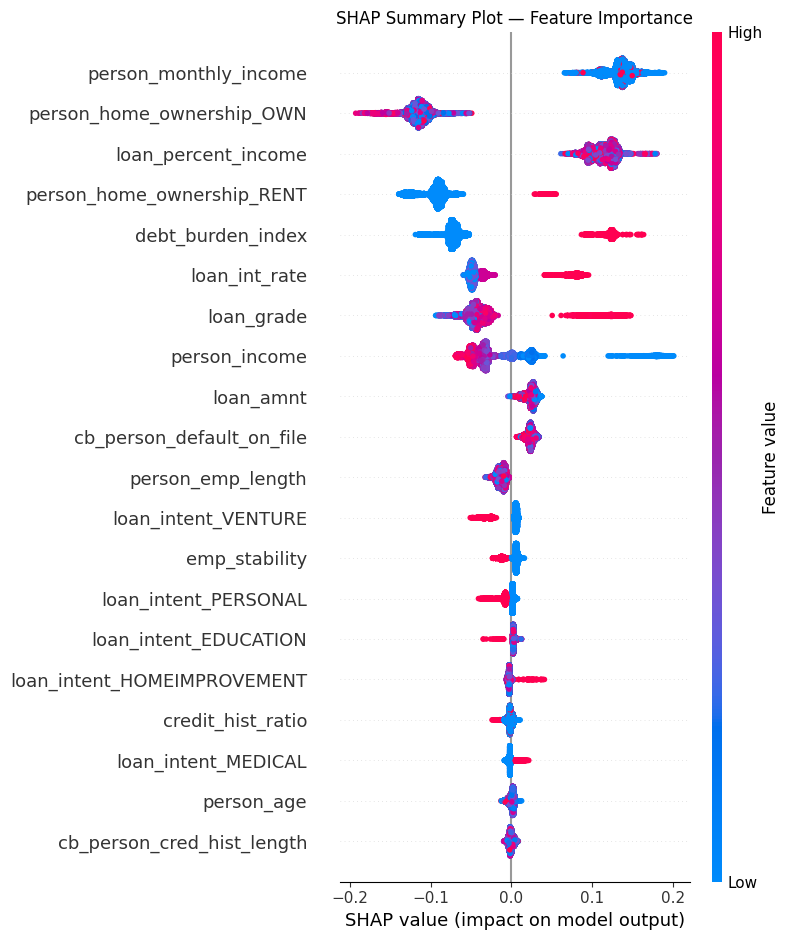

In [7]:
shap.summary_plot(
    shap_values[:, :, 1],
    x,
    feature_names = feature_columns,
    show=False
)
plt.title("SHAP Summary Plot — Feature Importance")
plt.tight_layout()
plt.savefig("../explainability/summery_plot.png", dpi=150, bbox_inches='tight')
plt.show()

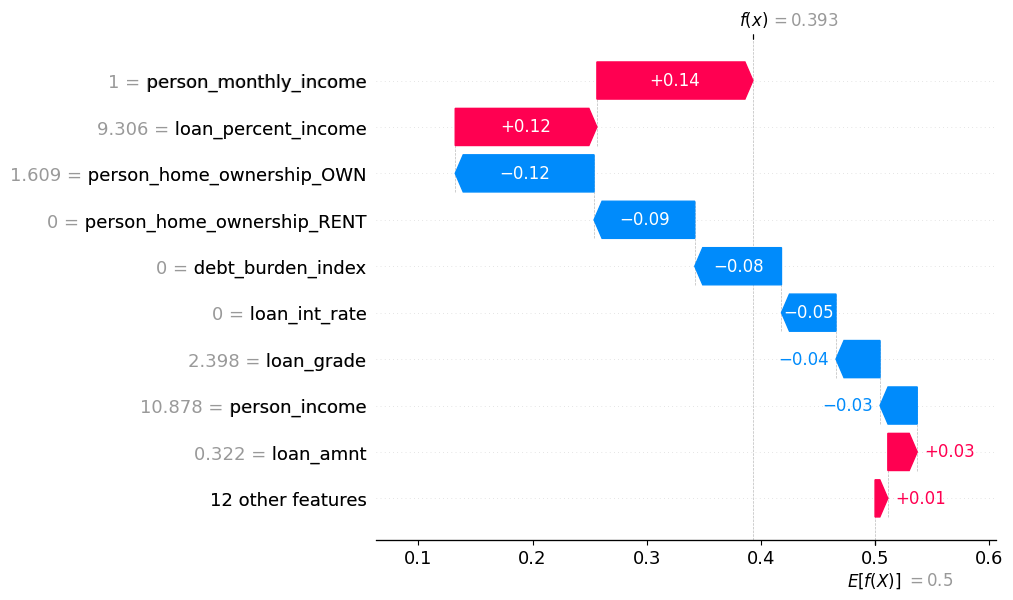

<Figure size 640x480 with 0 Axes>

In [9]:
row_index = 3244
shap.plots.waterfall(
    shap.Explanation(
        values=shap_values[row_index, :, 1],
        base_values=explainer.expected_value[1],
        data=x.iloc[row_index],
        feature_names=feature_columns
    )
)
plt.savefig("../explainability/specific_row_summery.png", dpi=150, bbox_inches='tight')